In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from google.colab import drive
drive.mount('/content/drive', force_remount=True)
df = pd.read_csv('/content/drive/MyDrive/twitter.csv')
df

Mounted at /content/drive


,Unnamed: 0,count,hate_speech,offensive_language,neither,class,tweet
0,0,3,0,0,3,2,!!! RT @mayasolovely: As a woman you shouldn't...
1,1,3,0,3,0,1,!!!!! RT @mleew17: boy dats cold...tyga dwn ba...
2,2,3,0,3,0,1,!!!!!!! RT @UrKindOfBrand Dawg!!!! RT @80sbaby...
3,3,3,0,2,1,1,!!!!!!!!! RT @C_G_Anderson: @viva_based she lo...
4,4,6,0,6,0,1,!!!!!!!!!!!!! RT @ShenikaRoberts: The shit you...
...,...,...,...,...,...,...,...
24778,25291,3,0,2,1,1,you's a muthaf***in lie &#8220;@LifeAsKing: @2...
24779,25292,3,0,1,2,2,"you've gone and broke the wrong heart baby, an..."
24780,25294,3,0,3,0,1,young buck wanna eat!!.. dat nigguh like I ain...
24781,25295,6,0,6,0,1,youu got wild bitches tellin you lies


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24783 entries, 0 to 24782
Data columns (total 7 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   Unnamed: 0          24783 non-null  int64 
 1   count               24783 non-null  int64 
 2   hate_speech         24783 non-null  int64 
 3   offensive_language  24783 non-null  int64 
 4   neither             24783 non-null  int64 
 5   class               24783 non-null  int64 
 6   tweet               24783 non-null  object
dtypes: int64(6), object(1)
memory usage: 1.3+ MB


In [3]:
df.describe()

,Unnamed: 0,count,hate_speech,offensive_language,neither,class
count,24783.000000,24783.000000,24783.000000,24783.000000,24783.000000,24783.000000
mean,12681.192027,3.243473,0.280515,2.413711,0.549247,1.109793
std,7299.553863,0.883060,0.631851,1.399459,1.113299,0.461943
min,0.000000,3.000000,0.000000,0.000000,0.000000,0.000000
25%,6372.500000,3.000000,0.000000,2.000000,0.000000,1.000000
50%,12703.000000,3.000000,0.000000,3.000000,0.000000,1.000000
75%,18995.500000,3.000000,0.000000,3.000000,0.000000,1.000000
max,25296.000000,9.000000,7.000000,9.000000,9.000000,2.000000


In [4]:
df[df['hate_speech'] != 0].shape[0]

4993

Text(0, 0.5, 'Number of words')

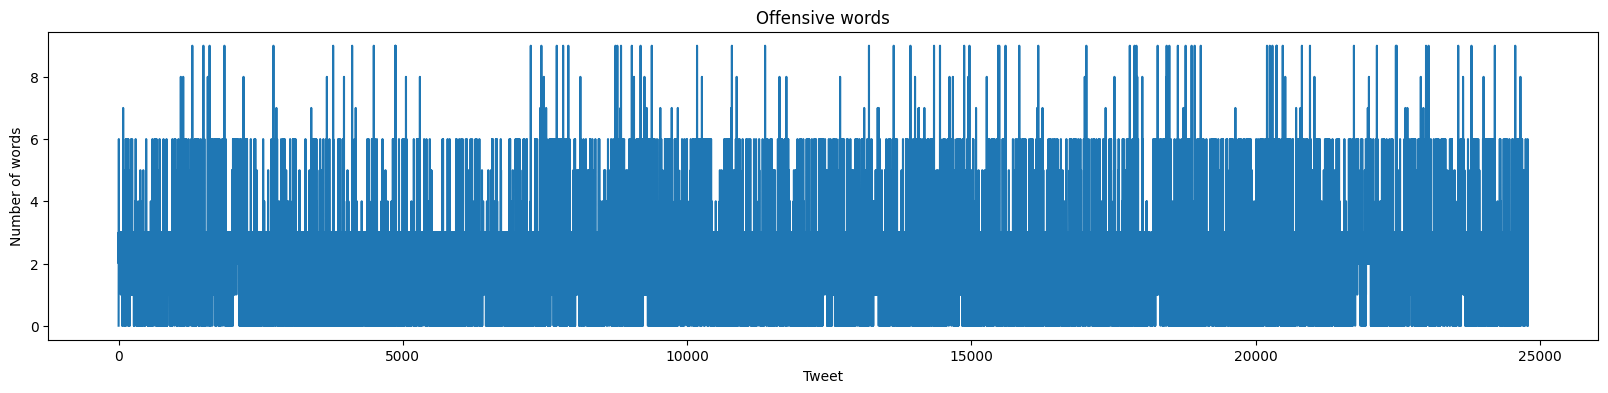

In [5]:
plt.figure(figsize=(20,4))
df['offensive_language'].plot.line(title="Offensive words")
plt.xlabel('Tweet')
plt.ylabel('Number of words')

In [6]:
df["labels"] = df["class"].map({0: "Hate Speech", 1: "Offensive Language", 2: "No Hate and Offensive"})
df

,Unnamed: 0,count,hate_speech,offensive_language,neither,class,tweet,labels
0,0,3,0,0,3,2,!!! RT @mayasolovely: As a woman you shouldn't...,No Hate and Offensive
1,1,3,0,3,0,1,!!!!! RT @mleew17: boy dats cold...tyga dwn ba...,Offensive Language
2,2,3,0,3,0,1,!!!!!!! RT @UrKindOfBrand Dawg!!!! RT @80sbaby...,Offensive Language
3,3,3,0,2,1,1,!!!!!!!!! RT @C_G_Anderson: @viva_based she lo...,Offensive Language
4,4,6,0,6,0,1,!!!!!!!!!!!!! RT @ShenikaRoberts: The shit you...,Offensive Language
...,...,...,...,...,...,...,...,...
24778,25291,3,0,2,1,1,you's a muthaf***in lie &#8220;@LifeAsKing: @2...,Offensive Language
24779,25292,3,0,1,2,2,"you've gone and broke the wrong heart baby, an...",No Hate and Offensive
24780,25294,3,0,3,0,1,young buck wanna eat!!.. dat nigguh like I ain...,Offensive Language
24781,25295,6,0,6,0,1,youu got wild bitches tellin you lies,Offensive Language


In [7]:
data = df[["tweet", "labels"]]
data

,tweet,labels
0,!!! RT @mayasolovely: As a woman you shouldn't...,No Hate and Offensive
1,!!!!! RT @mleew17: boy dats cold...tyga dwn ba...,Offensive Language
2,!!!!!!! RT @UrKindOfBrand Dawg!!!! RT @80sbaby...,Offensive Language
3,!!!!!!!!! RT @C_G_Anderson: @viva_based she lo...,Offensive Language
4,!!!!!!!!!!!!! RT @ShenikaRoberts: The shit you...,Offensive Language
...,...,...
24778,you's a muthaf***in lie &#8220;@LifeAsKing: @2...,Offensive Language
24779,"you've gone and broke the wrong heart baby, an...",No Hate and Offensive
24780,young buck wanna eat!!.. dat nigguh like I ain...,Offensive Language
24781,youu got wild bitches tellin you lies,Offensive Language


In [8]:
import re # regular expression
import nltk #natural language toolkit
import string # remove punctuation
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


True

In [9]:
# import stop words (non-significant words)
# Eg: As a woman you shouldn't complain about cleaning up your house -> Woman shouldn't complain clean house
from nltk.corpus import stopwords
stopwords = set(stopwords.words("english"))

In [10]:
# import steamming
#Eg: Cleaning/Cleaned -> Clean
stemmer = nltk.SnowballStemmer("english")

In [11]:
from nltk.stem import WordNetLemmatizer
lemmatizer = WordNetLemmatizer()

In [12]:
# Data Cleaning
def clean_data(text):
  text = str(text).lower() #As python is case sensitive
  text = re.sub('\[.*?\]', '', text) #symbols
  text = re.sub('https?://\S+|www\.\S+', '', text) #website
  text = re.sub('<.*?>+', '', text) #image
  text = re.sub('[%s]' %re.escape(string.punctuation), '', text) # \n, \t
  text = re.sub('\n', '', text)
  text = re.sub('\w"\d\w"', '', text)
  #Remove stopwords
  text = [word for word in text.split(' ') if word not in stopwords] # return if not stopword
  text = " ".join(text)
  #Stemming the text
  text = [stemmer.stem(word) for word in text.split(' ')]
  text = " ".join(text)
  words = text.split()
  words = [lemmatizer.lemmatize(word) for word in words if word not in stopwords]  # Lemmatize and remove stopwords
  return text

<>:4: SyntaxWarning: invalid escape sequence '\['
<>:5: SyntaxWarning: invalid escape sequence '\S'
<>:9: SyntaxWarning: invalid escape sequence '\w'
<>:4: SyntaxWarning: invalid escape sequence '\['
<>:5: SyntaxWarning: invalid escape sequence '\S'
<>:9: SyntaxWarning: invalid escape sequence '\w'
/tmp/ipykernel_13816/949239059.py:4: SyntaxWarning: invalid escape sequence '\['
  text = re.sub('\[.*?\]', '', text) #symbols
/tmp/ipykernel_13816/949239059.py:5: SyntaxWarning: invalid escape sequence '\S'
  text = re.sub('https?://\S+|www\.\S+', '', text) #website
/tmp/ipykernel_13816/949239059.py:9: SyntaxWarning: invalid escape sequence '\w'
  text = re.sub('\w"\d\w"', '', text)


In [13]:
df["tweet"] = df["tweet"].apply(clean_data)

In [14]:
df

,Unnamed: 0,count,hate_speech,offensive_language,neither,class,tweet,labels
0,0,3,0,0,3,2,rt mayasolov woman shouldnt complain clean ho...,No Hate and Offensive
1,1,3,0,3,0,1,rt mleew17 boy dat coldtyga dwn bad cuffin da...,Offensive Language
2,2,3,0,3,0,1,rt urkindofbrand dawg rt 80sbaby4lif ever fuc...,Offensive Language
3,3,3,0,2,1,1,rt cganderson vivabas look like tranni,Offensive Language
4,4,6,0,6,0,1,rt shenikarobert shit hear might true might f...,Offensive Language
...,...,...,...,...,...,...,...,...
24778,25291,3,0,2,1,1,yous muthafin lie 8220lifeask 20pearl coreyema...,Offensive Language
24779,25292,3,0,1,2,2,youv gone broke wrong heart babi drove redneck...,No Hate and Offensive
24780,25294,3,0,3,0,1,young buck wanna eat dat nigguh like aint fuck...,Offensive Language
24781,25295,6,0,6,0,1,youu got wild bitch tellin lie,Offensive Language


In [15]:
X = data["tweet"].values
y = np.array(data["labels"])

In [16]:
X

array(["!!! RT @mayasolovely: As a woman you shouldn't complain about cleaning up your house. &amp; as a man you should always take the trash out...",
       '!!!!! RT @mleew17: boy dats cold...tyga dwn bad for cuffin dat hoe in the 1st place!!',
       '!!!!!!! RT @UrKindOfBrand Dawg!!!! RT @80sbaby4life: You ever fuck a bitch and she start to cry? You be confused as shit',
       ...,
       'young buck wanna eat!!.. dat nigguh like I aint fuckin dis up again',
       'youu got wild bitches tellin you lies',
       '~~Ruffled | Ntac Eileen Dahlia - Beautiful color combination of pink, orange, yellow &amp; white. A Coll http://t.co/H0dYEBvnZB'],
      dtype=object)

In [17]:
from sklearn.model_selection import train_test_split

In [18]:
from sklearn.feature_extraction.text import TfidfVectorizer # better than CountVectorizer
tfidf = TfidfVectorizer() #Term frequency - Inverse Document frequency in NLP conver text to numerical
X = tfidf.fit_transform(df["tweet"])

In [19]:
X

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 212067 stored elements and shape (24783, 33740)>

In [20]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=69)
# 33% data from test and 67% to train

In [21]:
X_train

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 142307 stored elements and shape (16604, 33740)>

In [22]:
from sklearn.tree import DecisionTreeClassifier

In [23]:
dt = DecisionTreeClassifier()
dt.fit(X_train, y_train)

DecisionTreeClassifier()

In [24]:
from sklearn.svm import SVC
model = SVC(kernel='linear')  # SVM works well for text classification
model.fit(X_train, y_train)

SVC(kernel='linear')

In [25]:
y_pred1 = dt.predict(X_test)

In [26]:
y_pred = model.predict(X_test)

In [27]:
from sklearn.metrics import confusion_matrix
cm1 = confusion_matrix(y_test, y_pred1)
cm1

array([[ 118,   53,  299],
       [  32, 1171,  188],
       [ 248,  265, 5805]])

In [28]:
# Confusion Matric and accuracy
cm = confusion_matrix(y_test, y_pred)
cm

array([[  65,   45,  360],
       [   5, 1240,  146],
       [  44,  179, 6095]])

In [29]:
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

<Axes: >

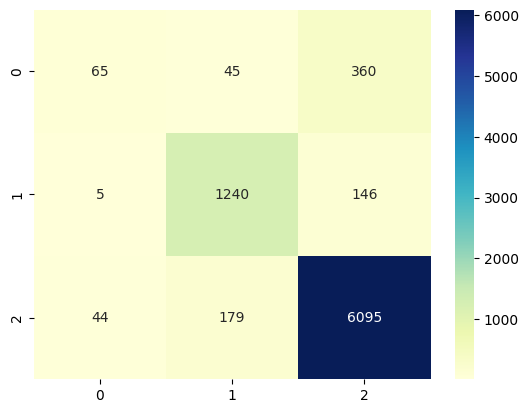

In [30]:
sns.heatmap(cm, annot = True, fmt="d", cmap="YlGnBu")

In [31]:
from sklearn.metrics import accuracy_score
print('Accuracy =', 100*accuracy_score(y_test, y_pred), '%')

Accuracy = 90.47560826506907 %


In [32]:
print('Accuracy =', 100*accuracy_score(y_test, y_pred1), '%')

Accuracy = 86.73431959897297 %


In [33]:
sample1 = "Expel the jews"
sample1 = clean_data(sample1)

sample1

'expel jew'

In [34]:
data1 = tfidf.transform([sample1]).toarray()
data1

array([[0., 0., 0., ..., 0., 0., 0.]])

In [35]:
model.predict(data1)

array(['Hate Speech'], dtype=object)